# CNN Layer Specifications & Dimensions

This document details the mathematical operations and dimension transformations for each layer in the implemented CNN, adhering strictly to the notation conventions established in `ML_Note10_1.ipynb`.

## Notation Key (from `ML_Note10_1.ipynb`)

- $N$: Number of training examples (Batch Size)
- $L$: Number of conv layers
- $FC_l$: Fully connected layer $l$

### Convolution Parameters
- $X^l$: Input of layer $l$, shape $(N, X_C^l, X_H^l, X_W^l)$
- $f_n^l$: Number of filters in conv layer $l$
- $f_{size}^l$: Filter size in conv layer $l$
- $f_c^l$: Filter channel in conv layer $l$ (must equal $X_C^l$)
- $f_s^l$: Stride of filters in conv layer $l$
- $f_p^l$: Padding of filters in conv layer $l$

### Output Dimensions
- $Z_H^l = \lfloor \frac{X_H^l + 2f_p^l - f_{size}^l}{f_s^l} \rfloor + 1$
- $Z_W^l = \lfloor \frac{X_W^l + 2f_p^l - f_{size}^l}{f_s^l} \rfloor + 1$
- $Z_C^l = f_n^l$

## 1. Convolutional Layer (`Conv`)

### Forward Propagation

**Input:**
- $X^l$: Shape $(N, X_C^l, X_H^l, X_W^l)$

**Parameters:**
- $F_{col}^l$: Filters, Shape $(f_c^l \cdot f_{size}^l \cdot f_{size}^l, f_n^l)$
- $b^l$: Bias, Shape $(1, f_n^l)$

**Operation:**
1. **Im2Col Transformation:**
   $$ X_{col}^l = \text{img2col}(X^l) $$
   - $X_{col}^l$ Shape: $(N \cdot Z_H^l \cdot Z_W^l, f_c^l \cdot f_{size}^l \cdot f_{size}^l)$

2. **Linear Transformation:**
   $$ Z_{flat}^l = X_{col}^l \cdot F_{col}^l + b^l $$
   - $Z_{flat}^l$ Shape: $(N \cdot Z_H^l \cdot Z_W^l, f_n^l)$

3. **Reshape:**
   $$ Z^l = \text{reshape}(Z_{flat}^l) $$
   - $Z^l$ Shape: $(N, Z_C^l, Z_H^l, Z_W^l)$  *(Note: Code typically outputs $(N, f_n^l, Z_H^l, Z_W^l)$)*

### Backward Propagation

**Input Gradient:**
- $dZ^l$: Shape $(N, Z_C^l, Z_H^l, Z_W^l)$

**Gradients:**
1. **Weights Gradient:**
   $$ dF_{col}^l = (X_{col}^l)^T \cdot dZ_{flat}^l $$
   - $dF_{col}^l$ Shape: $(f_c^l \cdot f_{size}^l \cdot f_{size}^l, f_n^l)$

2. **Bias Gradient:**
   $$ db^l = \sum dZ_{flat}^l $$
   - $db^l$ Shape: $(1, f_n^l)$

3. **Input Gradient (for previous layer):**
   $$ dX_{col}^l = dZ_{flat}^l \cdot (F_{col}^l)^T $$
   $$ dX^l = \text{col2img}(dX_{col}^l) $$
   - $dX^l$ Shape: $(N, X_C^l, X_H^l, X_W^l)$

## 2. Pooling Layer (`Pooling`)

### Forward Propagation

**Input:**
- $A^{l-1}$ (or $Z^{l-1}$): Shape $(N, Z_H^{l-1}, Z_W^{l-1}, f_n^{l-1})$

**Parameters:**
- $P_{size}^l$: Pooling window size
- $P_s^l$: Stride
- $P_p^l$: Padding

**Output Dimensions:**
- $Z_H^l = \lfloor \frac{Z_H^{l-1} - P_{size}^l}{P_s^l} \rfloor + 1$
- $Z_W^l = \lfloor \frac{Z_W^{l-1} - P_{size}^l}{P_s^l} \rfloor + 1$
- $Z_C^l = f_n^{l-1}$

**Operation (Max Pooling):**
$$ X_{col}^l = \text{img2col}(A^{l-1}, \text{filter\_size}=P_{size}^l, \text{stride}=P_s^l) $$
$$ A^l = \max(X_{col}^l) $$
- $A^l$ Shape: $(N, Z_C^l, Z_H^l, Z_W^l)$

### Backward Propagation

**Input Gradient:**
- $dA^l$: Shape $(N, Z_C^l, Z_H^l, Z_W^l)$

**Operation:**
- Gradients are routed back to the index of the maximum value within each window.
- $dA^{l-1}$ Shape: $(N, Z_H^{l-1}, Z_W^{l-1}, f_n^{l-1})$

## 3. Fully Connected Layer (`FC`)

**Note on Dimensions:** 
This layer uses a **(Features, Batch Size)** convention, denoted as $(D^{FC_l}, N)$, unlike the Conv/Pool layers which use $(N, X_C^l, X_H^l, X_W^l)$.

**Input Transformation:**
If input comes from Conv/Pool layer:
$$ A^{FC_{l-1}} = \text{flatten}(A^{L})^T $$
- $A^{FC_{l-1}}$ Shape: $(D^{FC_{l-1}}, N)$ where $D^{FC_{l-1}} = Z_C^L \cdot Z_H^L \cdot Z_W^L$

### Forward Propagation

**Input:**
- $A^{FC_{l-1}}$: Shape $(D^{FC_{l-1}}, N)$

**Parameters:**
- $W^{FC_l}$: Weights, Shape $(D^{FC_{l-1}}, D^{FC_l})$
- $b^{FC_l}$: Bias, Shape $(D^{FC_l}, 1)$

**Operation:**
$$ Z^{FC_l} = (W^{FC_l})^T \cdot A^{FC_{l-1}} + b^{FC_l} $$
- $Z^{FC_l}$ Shape: $(D^{FC_l}, N)$

### Backward Propagation

**Input Gradient:**
- $dZ^{FC_l}$: Shape $(D^{FC_l}, N)$

**Gradients:**
1. **Weights Gradient:**
   $$ dW^{FC_l} = \frac{1}{N} (A^{FC_{l-1}} \cdot (dZ^{FC_l})^T) $$
   - $dW^{FC_l}$ Shape: $(D^{FC_{l-1}}, D^{FC_l})$

2. **Bias Gradient:**
   $$ db^{FC_l} = \frac{1}{N} \sum_{rows} dZ^{FC_l} $$
   - $db^{FC_l}$ Shape: $(D^{FC_l}, 1)$

3. **Input Gradient:**
   $$ dA^{FC_{l-1}} = W^{FC_l} \cdot dZ^{FC_l} $$
   - $dA^{FC_{l-1}}$ Shape: $(D^{FC_{l-1}}, N)$

## 4. Activation Layer (`Activation`)

### Forward Propagation

**Operation:**
$$ A_W^l = Z_W^l, \quad A_H^l = Z_H^l, \quad A_C^l = Z_C^l $$
$$ A^l = g(Z^l) $$
where $g$ is the activation function (ReLU, Sigmoid, Softmax, etc.).

- **ReLU:** $A^l = \max(0, Z^l)$
- **Sigmoid:** $A^l = \frac{1}{1 + e^{-Z^l}}$
- **Softmax:** $A_i^l = \frac{e^{Z_i^l}}{\sum e^{Z_j^l}}$

**Dimensions:** Output $A^l$ has same shape as Input $Z^l$.

### Backward Propagation

**Operation:**
$$ dZ^l = dA^l \odot g'(Z^l) $$

- **ReLU:** $dZ^l = dA^l \odot \mathbb{I}(Z^l > 0)$
- **Sigmoid:** $dZ^l = dA^l \odot A^l \odot (1 - A^l)$

## 5. Batch Normalization (`BatchNorm`)

This layer normalizes input $Z$ to have zero mean and unit variance per feature channel.

### Forward Propagation

**Parameters:**
- $\gamma$: Scale parameter
- $\beta$: Shift parameter

**Dimensions:**
- **For Conv Outputs $(N, Z_C^l, Z_H^l, Z_W^l)$:** $\gamma, \beta$ shape is $(1, Z_C^l, Z_H^l, Z_W^l)$. Mean/Var computed over axis 0 ($N$).
- **For FC Outputs $(D^{FC_l}, N)$:** $\gamma, \beta$ shape is $(D^{FC_l}, 1)$. Mean/Var computed over axis 1 ($N$).

**Operation:**
1. **Mean & Variance:**
   $$ \mu = \frac{1}{N} \sum Z^l $$
   $$ \sigma^2 = \frac{1}{N} \sum (Z^l - \mu)^2 $$

2. **Normalize:**
   $$ \hat{Z}^l = \frac{Z^l - \mu}{\sqrt{\sigma^2 + \epsilon}} $$

3. **Scale & Shift:**
   $$ \tilde{Z}^l = \gamma \cdot \hat{Z}^l + \beta $$

### Backward Propagation

**Input Gradient:** $d\tilde{Z}^l$

**Gradients:**
$$ d\gamma = \sum (d\tilde{Z}^l \odot \hat{Z}^l) $$
$$ d\beta = \sum d\tilde{Z}^l $$
$$ dZ^l = \frac{\gamma}{\sqrt{\sigma^2 + \epsilon}} \left( d\tilde{Z}^l - \frac{1}{N}d\beta - \frac{\hat{Z}^l}{N}d\gamma \right) $$

*(Summation matches the batch axis used in forward pass)*

## 6. Im2Col and Col2Img Detailed Algorithm

### 6.1 Im2Col (Image to Column)

Im2Col is a pivotal operation in optimizing Convolutional Neural Networks. It transforms the convolution operation into a highly efficient Matrix-Matrix Multiplication (GEMM).

#### Concept
The 3D input tensor $X$ (batch, channel, height, width) is rearranged into a 2D matrix $X_{col}$. Each column of $X_{col}$ corresponds to a receptive field (local patch) in the input image that the filter will operate on.

#### Algorithm
Given input $X$ of shape $(N, C, H, W)$ and kernel size $(f, f)$:
1. **Extract Patches:** For each output spatial location $(i, j)$:
   - Extract a 3D patch of size $(C, f, f)$ from the input starting at that stride location.
   - Flatten this patch into a column vector of size $C \cdot f \cdot f$.
2. **Stack Columns:** Repeat for all $N$ images and all spatial locations.
   - Total columns per image = $H_{out} \cdot W_{out}$.
   - Total columns in batch = $N \cdot H_{out} \cdot W_{out}$.

**Result:**
A matrix $X_{col}$ of shape $(N \cdot H_{out} \cdot W_{out}, C \cdot f \cdot f)$.

#### Visual Illustration
![Im2Col Illustration](layer_viz/img2col_illustration.png)
*(Im2Col: Sliding window extracts patches, which are flattened into columns)*

#### Animation
![Im2Col Animation](layer_viz/img2col_animation.gif)

#### Code Implementation (NumPy Stride Tricks - Vectorization)

In our implementation (`CNN.py`), we use `numpy.lib.stride_tricks.as_strided` to create the `X_{col}` view **without copying memory**. This is a form of **virtual vectorization** that avoids expensive data movement.

**How `as_strided` Works (Vectorization Principle):**

The function `as_strided` does **not copy data**. Instead, it creates a new "view" of the same memory by only changing how NumPy interprets the array's **strides** (bytes to skip for each dimension). 

**Memory Layout vs. Logical View:**

- **Original Array `X_padded`:** Shape $(N, C, H, W)$ stored in memory as contiguous bytes.
- **Physical Memory:** Linear storage: `[image_0, channel_0, row_0, col_0, ..., image_N-1, ...]`
- **Strides:** For array `arr`, `arr.strides` tells us "how many bytes to skip" when incrementing each index.

**Example Stride Calculation:**
```python
# If X_padded has shape (N, C, H, W) = (2, 1, 4, 4)
# Each element is 8 bytes (float64)
# Original strides: 
s_n = C * H * W * 8  # Skip entire first image to reach second image
s_c = H * W * 8      # Skip entire first channel to reach next channel  
s_h = W * 8          # Skip entire row to reach next row
s_w = 8              # Skip one element to reach next column
```

**Creating the 6D Virtual View:**

By specifying `new_strides`, we tell NumPy:
- **Dimension 2 (`h_out`):** Jump by `s_h * stride` bytes → This skips multiple rows to reach the *next patch* in the vertical direction.
- **Dimension 5 (`filter_size` within patch):** Jump by `s_h` bytes → This moves *within* the patch (one row down).

**Result:** The same memory block is now interpreted as a 6D array $(N, h\_out, w\_out, C, k, k)$, where dimensions 4-5 represent the sliding window itself.

**Key Vectorization Benefit:** Instead of looping over $N \times h_{out} \times w_{out}$ patches and copying each patch, `as_strided` creates all patches **virtually** in $O(1)$ time. Only when the array is actually used (e.g., in matrix multiplication) does NumPy perform the memory access.

```python
def img2col(X:np.ndarray, filter_size:int, filter_c:int, stride:int = 1, padding:tuple[int,int]=(0,0), dilation:int = 1)->np.ndarray:
    # ... (padding logic) ...
    
    # Create view with as_strided
    # new_shape: (N, h_out, w_out, C, filter_size, filter_size)
    new_shape = (N, h_out, w_out, C, filter_size, filter_size)
    s_n, s_c, s_h, s_w = X_padded.strides
    
    # new_strides defines how to move in memory for each dimension
    # 1. N: Move to next image (s_n)
    # 2. h_out: Move to next vertical patch (s_h * stride) ← Vectorized: skips stride rows
    # 3. w_out: Move to next horizontal patch (s_w * stride) ← Vectorized: skips stride cols
    # 4. C: Move to next channel (s_c)
    # 5. filter_size (h): Move vertically within patch (s_h)
    # 6. filter_size (w): Move horizontally within patch (s_w)
    new_strides = (s_n, s_h * stride, s_w * stride, s_c, s_h, s_w)
    
    X_col = as_strided(X_padded, shape=new_shape, strides=new_strides)
    # No memory copy! Just a new "lens" to view the same data.
    return X_col
```

---

### 6.2 Col2Img (Column to Image)

Col2Img is the reverse operation, primarily used during backpropagation to map gradients from the column format back to the original image structure.

#### Concept (Gradient Accumulation)
The gradients calculated on the flattened matrix $dZ_{flat}$ need to be distributed back to the original pixels in $dX$. Since Im2Col duplicates pixels (due to overlapping receptive fields), Col2Img must **accumulate** (sum) these gradients where overlaps occur.

#### Algorithm (Optimized)
A naive 6-loop implementation is slow. We optimize by looping only over the *filter dimensions* (which are small, e.g., 3x3) and vectorizing the batch and spatial locations.

1. **Loop over Filter Pixels:** Iterate `fh` from 0 to `f_size-1` and `fw` from 0 to `f_size-1`.
2. **Extract Gradient Slice:** For a fixed `(fh, fw)`, extract the gradients corresponding to this filter pixel position across all windows and images.
3. **Accumulate:** Add this slice to the output $dX$ at the corresponding stride-shifted positions.

#### Visual Illustration
![Col2Img Illustration](layer_viz/col2img_illustration.png)
*(Col2Img: Gradients from different filter positions are accumulated into the target pixels)*

#### Animation
![Col2Img Animation](layer_viz/col2img_animation.gif)
*(Animation showing the loop over filter dimensions: slices are added to dX sequentially)*

#### Code Implementation (Vectorization by Filter Dimension Loop)

**Vectorization Strategy:**

A naive 6-loop implementation would iterate over all dimensions:
```python
# Naive (slow): O(N × h_out × w_out × C × fh × fw)
for n in range(N):
    for i in range(h_out):
        for j in range(w_out):
            for c in range(C):
                for fh in range(filter_size):
                    for fw in range(filter_size):
                        # ... accumulate ...
```

Instead, we **vectorize** by looping only over filter dimensions $(fh, fw)$ and processing all other dimensions in bulk.

**Vectorized Implementation:**

```python
def col2img(X_col:np.ndarray, stride:int=1, padding:tuple=(0,0))->np.ndarray:
    # ... (init output) ...
    
    # Loop only over filter dimensions (small constant: O(k²) where k=filter_size)
    # This vectorizes over N, h_out, w_out, and C simultaneously!
    for fh in range(filter_size):
        for fw in range(filter_size):
            # 1. Vectorized extraction: Extract ALL gradients for filter pixel (fh, fw)
            #    This single slicing operation processes ALL (N, h_out, w_out, C) in one go.
            #    Shape: (N, h_out, w_out, C) ← ALL batch/spatial/channel data at once
            val = X_col[:, :, :, :, fh, fw]  # Vectorized across N, h_out, w_out, C
            
            # 2. Calculate target region in dX
            #    All gradients in 'val' need to be placed at offset (fh, fw) in the output
            h_start = fh
            h_end = fh + h_out * stride
            w_start = fw
            w_end = fw + w_out * stride
            
            # 3. Vectorized accumulation: += operates on entire array at once
            #    This single operation adds val to X_padded at the stride-shifted positions
            #    for ALL (N, h_out, w_out, C) simultaneously.
            #    Note: Slicing with stride allows NumPy's vectorized += to handle all positions.
            X_padded[:, :, h_start:h_end:stride, w_start:w_end:stride] += val.transpose(0, 3, 1, 2)
    
    # ... (remove padding) ...
    return X_padded
```

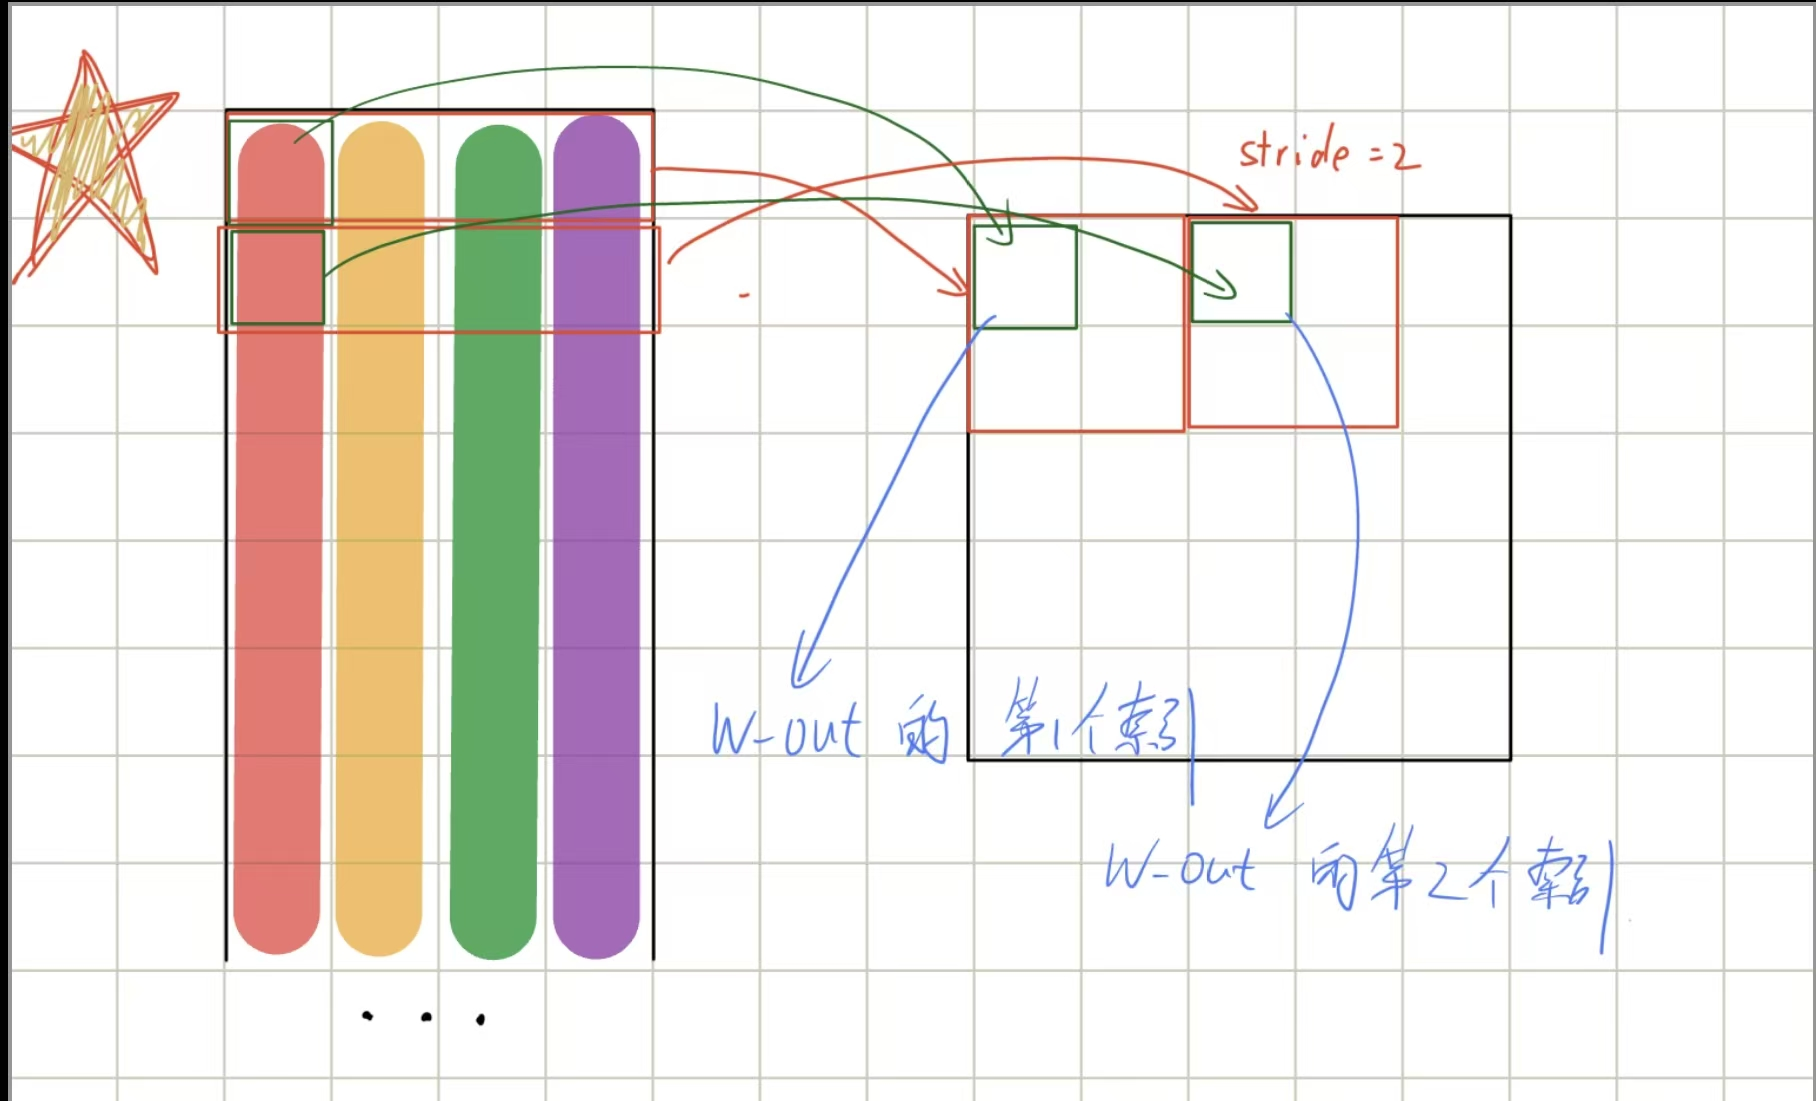
